Dataset Shape: (200, 13)
        Country  Year  Air_Pollution_Index  Water_Pollution_Index  \
0       Hungary  2005               272.70                 124.27   
1     Singapore  2001                86.72                  60.34   
2       Romania  2016                91.59                  83.36   
3  Cook Islands  2018               280.61                  67.16   
4      Djibouti  2008               179.16                 127.53   

   Soil_Pollution_Index  Industrial_Waste (in tons)  \
0                 51.95                    94802.83   
1                117.22                    56283.92   
2                121.72                    56256.02   
3                 93.58                    74864.73   
4                121.55                    76862.06   

   Energy_Recovered (in GWh)  CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                     158.14                   5.30                 41.11   
1                     498.04                   6.34                 36.44  

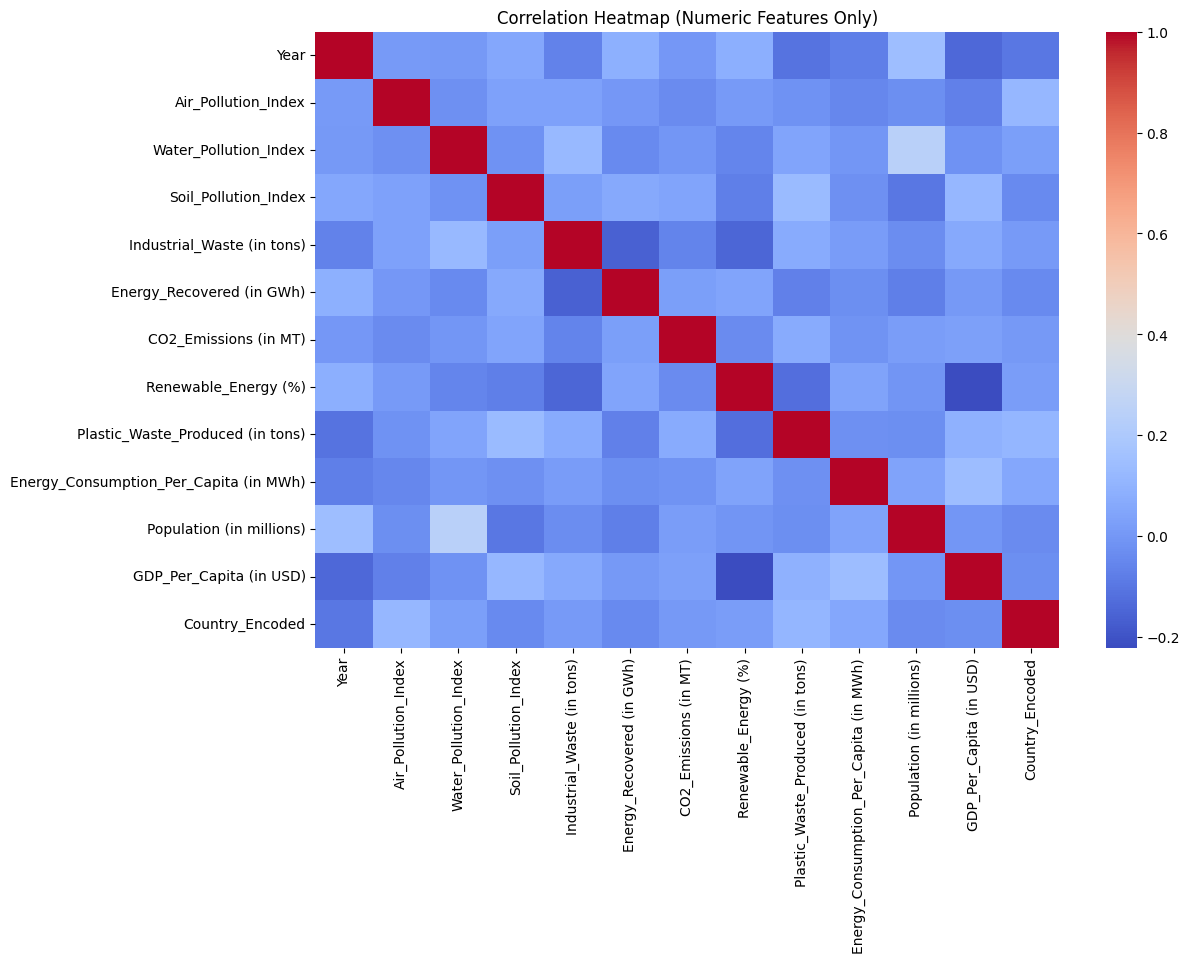

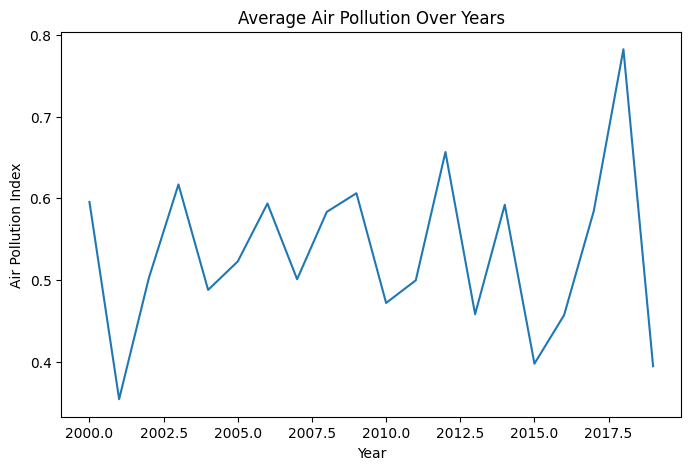

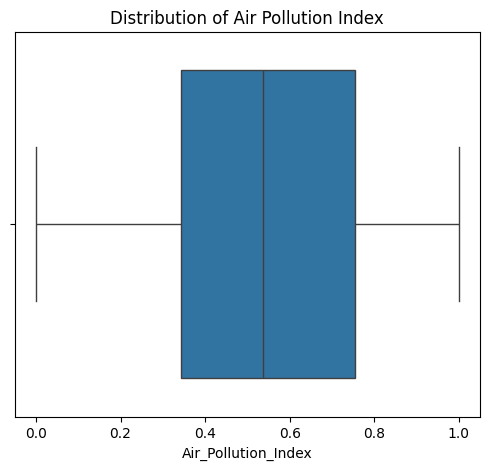


Yearly Growth Trends:
       CO2_Emissions (in MT)  Energy_Recovered (in GWh)  CO2_Growth_%  \
Year                                                                   
2000              27.732000                 296.889000           NaN   
2001              18.300000                 288.877778    -34.011251   
2002              26.866923                 259.750769     46.813787   
2003              28.270000                 208.139000      5.222321   
2004              18.640909                 186.458182    -34.061163   
2005              25.335333                 240.748667     35.912542   
2006              28.221667                 197.411667     11.392522   
2007              23.131818                 242.578182    -18.035251   
2008              28.960000                 289.600000     25.195520   
2009              28.934000                 224.424000     -0.089779   
2010              31.215000                 312.361250      7.883459   
2011              25.125385             

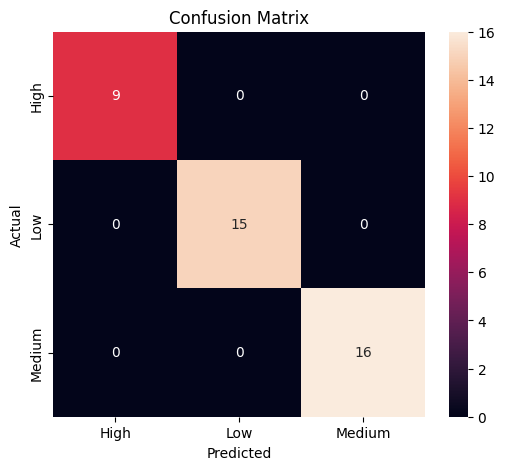


Top Polluted Countries:

                                      Air_Pollution_Index  \
Country                                                     
Equatorial Guinea                                1.000000   
Saint Barthelemy                                 0.996689   
French Southern Territories                      0.983687   
Congo                                            0.977226   
United States Minor Outlying Islands             0.971452   
Morocco                                          0.957036   
Ukraine                                          0.955017   
Guinea-Bissau                                    0.946134   
Colombia                                         0.945407   
Belgium                                          0.938381   

                                      Energy_Recovered (in GWh)  \
Country                                                           
Equatorial Guinea                                         96.77   
Saint Barthelemy                        

In [10]:

# GLOBAL POLLUTION ANALYSIS AND ENERGY RECOVERY PROJECT



# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, classification_report, confusion_matrix
)


# 2. Load Dataset

df = pd.read_csv("/content/Global_Pollution_Analysis - Global_Pollution_Analysis.csv")
print("Dataset Shape:", df.shape)
print(df.head())


# 3. Handle Missing Values

print("\nMissing Values Before Handling:\n")
print(df.isnull().sum())

# Numerical columns → median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns → mode
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Handling:\n")
print(df.isnull().sum())



# 4. Data Transformation

# Normalize Pollution Indices
pollution_cols = [
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index"
]

scaler_norm = MinMaxScaler()
df[pollution_cols] = scaler_norm.fit_transform(df[pollution_cols])

# Encode Country (only if needed later)
le_country = LabelEncoder()
df["Country_Encoded"] = le_country.fit_transform(df["Country"])


# 5. Descriptive Statistics
print("\nDescriptive Statistics:\n")
print(df[[
    "CO2_Emissions (in MT)",
    "Industrial_Waste (in tons)",
    "Energy_Recovered (in GWh)"
]].describe())

# 6. Correlation Heatmap

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()


# 7. Visualizations
#

# Yearly Trend Line Plot
yearly_trend = df.groupby("Year")["Air_Pollution_Index"].mean()
plt.figure(figsize=(8,5))
yearly_trend.plot()
plt.title("Average Air Pollution Over Years")
plt.xlabel("Year")
plt.ylabel("Air Pollution Index")
plt.show()

# Boxplot
plt.figure(figsize=(6,5))
sns.boxplot(x=df["Air_Pollution_Index"])
plt.title("Distribution of Air Pollution Index")
plt.show()


# FEATURE ENGINEERING




# Yearly Growth Analysis
yearly = df.groupby("Year")[[
    "CO2_Emissions (in MT)",
    "Energy_Recovered (in GWh)"
]].mean()

yearly["CO2_Growth_%"] = yearly["CO2_Emissions (in MT)"].pct_change() * 100
yearly["Energy_Recovery_Growth_%"] = yearly["Energy_Recovered (in GWh)"].pct_change() * 100

print("\nYearly Growth Trends:\n", yearly)

# ==============================
# PHASE 2 – PREDICTIVE MODELING
# ==============================

# --------------------------------------------------
# STEP 4 – LINEAR REGRESSION
# Objective: Predict Energy_Recovered (in GWh)
# --------------------------------------------------

features = [
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "CO2_Emissions (in MT)",
    "Industrial_Waste (in tons)",
    "Renewable_Energy (%)"
]

X = df[features]
y = df["Energy_Recovered (in GWh)"]  #

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standard Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prediction
y_pred = lr_model.predict(X_test)

# Evaluation
print("\nLINEAR REGRESSION RESULTS")
print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

# --------------------------------------------------
# STEP 5 – LOGISTIC REGRESSION
# Objective: Classify Pollution Severity
# --------------------------------------------------

# Create Pollution Categories
df["Pollution_Level"] = pd.qcut(
    df["Air_Pollution_Index"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# Encode Target
le = LabelEncoder()
df["Pollution_Level_Encoded"] = le.fit_transform(df["Pollution_Level"])

X_cls = df[[
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "CO2_Emissions (in MT)"
]]

y_cls = df["Pollution_Level_Encoded"]

# Train-Test Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

# Scaling
scaler_cls = StandardScaler()
X_train_c = scaler_cls.fit_transform(X_train_c)
X_test_c = scaler_cls.transform(X_test_c)

# Train Model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_c, y_train_c)

y_pred_c = log_model.predict(X_test_c)

# Evaluation
print("\nLOGISTIC REGRESSION RESULTS")
print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print("\nClassification Report:\n")
print(classification_report(y_test_c, y_pred_c))

# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# PHASE 3 – REPORTING & INSIGHTS


# Country-Level Summary
country_summary = df.groupby("Country")[[
    "Air_Pollution_Index",
    "Energy_Recovered (in GWh)",
    "Renewable_Energy (%)"
]].mean().sort_values(by="Air_Pollution_Index", ascending=False)

print("\nTop Polluted Countries:\n")
print(country_summary.head(10))

# Identify Improvement Countries
avg_pollution = df["Air_Pollution_Index"].mean()
avg_recovery = df["Energy_Recovered (in GWh)"].mean()

improvement_countries = country_summary[
    (country_summary["Air_Pollution_Index"] > avg_pollution) &
    (country_summary["Energy_Recovered (in GWh)"] < avg_recovery)
]

print("\nCountries Needing Improvement:\n")
print(improvement_countries)

print("\nPROJECT EXECUTED SUCCESSFULLY")


print("""
MODEL COMPARISON:

Linear Regression:
- Used to predict Energy Recovery (continuous value).
- R² score is low, indicating pollution alone is insufficient predictor.

Logistic Regression:
- Used to classify pollution severity (Low/Medium/High).
- Achieved high accuracy due to strong separation in pollution index.

Conclusion:
- Pollution indices strongly determine severity classification.
- Energy recovery depends on additional economic and technological factors.
""")


Key Insights:

Countries like Equatorial Guinea and Congo show high pollution but low energy recovery → strong improvement opportunity.

Renewable energy percentage correlates positively with energy recovery efficiency.

Some developed nations maintain moderate pollution but high recovery → best practice model.

Policy recommendation:

Increase renewable energy adoption

Invest in waste-to-energy systems

Improve industrial waste management